# Swimming VR

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scripts import preprocessing

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Data preprocessing

In [ ]:
sub_nums=[2,]

data/phase_0/baseline/sub_2/real


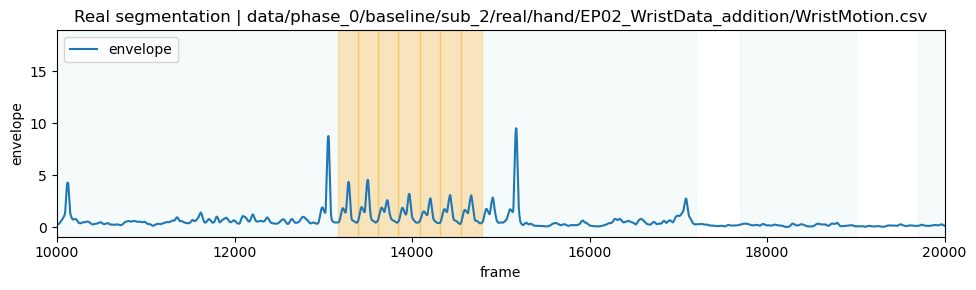

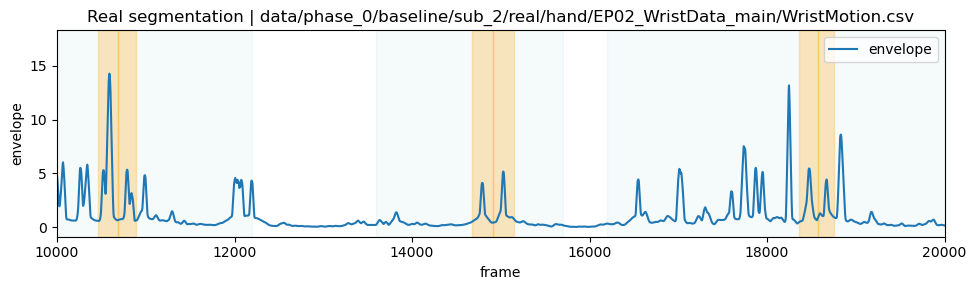

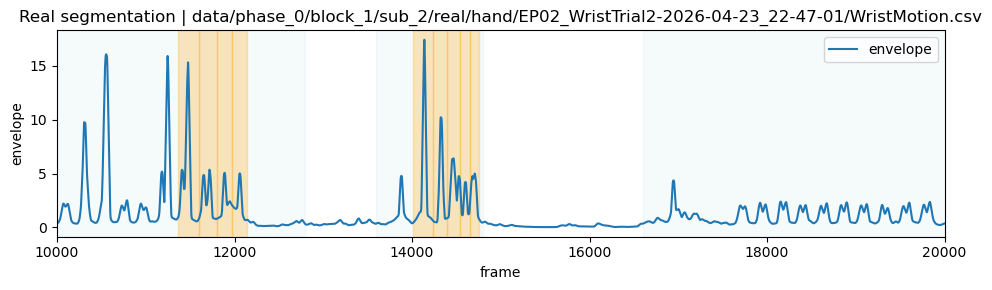

In [ ]:
feature_dict = {
    "real": {
        "head": ["pitch", "roll", "yaw"],
        "left_hand": ["pitch", "roll", "yaw"],
    },
    "vr": {
        "head": ["HeadX", "HeadY", "HeadZ", "HeadPitch", "HeadYaw", "HeadRoll"],
        "left_hand": ["LeftX_norm", "LeftY_norm", "LeftZ_norm"],
        "right_hand": ["RightX_norm", "RightY_norm", "RightZ_norm"],
    }
}

norm_dict = {
    "real": {
        "head": {
            "pitch": "range_pi",
            "roll": "range_pi",
            "yaw": "range_pi",
        },
        "left_hand": {
            "pitch": "range_pi",
            "roll": "range_pi",
            "yaw": "range_pi",
        },
    },
    "vr": {
        "head": {
            "HeadX": "zscore",
            "HeadY": "zscore",
            "HeadZ": "zscore",
            "HeadPitch": "range_pi",
            "HeadYaw": "range_pi",
            "HeadRoll": "range_pi",
        },
        "left_hand": {
            "LeftX_norm": "zscore",
            "LeftY_norm": "zscore",
            "LeftZ_norm": "zscore",
        },
        "right_hand": {
            "RightX_norm": "zscore",
            "RightY_norm": "zscore",
            "RightZ_norm": "zscore",
        },
    }
}

swim_dict = preprocessing.process_swim_phase(
    data_root="data",
    phase_j=0,
    PIDS=sub_nums,
    feature_dict=feature_dict,
    norm_dict=norm_dict,
    fs_dict={
        "real": 100,
        "vr": 24,
    },
    filter_cfg={
        "lowcut": 0.2,
        "highcut": 10.0,
        "order": 4,
    },
    n_bins=50,
    valid_rep_time_range=(0.8, 2.5),
    peak_height=2.5,
)

In [132]:
X_base = swim_dict["sub_2"]["baseline"]
X_b1_real = swim_dict["sub_2"]["block_1"]["real"]
X_b1_vr = swim_dict["sub_2"]["block_1"]["vr"]

print(X_base.shape)    # (N, T, D)
print(X_b1_real.shape) # (N, T, D)
print(X_b1_vr.shape)   # (N, T, D)

for key, item in swim_dict["sub_2"]["feature_cols"].items():
    print(key)
    print(item)

(29, 50, 12)
(38, 50, 12)
(63, 50, 24)
baseline
['head_pitch', 'head_roll', 'head_yaw', 'head_pitch_vel', 'head_roll_vel', 'head_yaw_vel', 'left_hand_pitch', 'left_hand_roll', 'left_hand_yaw', 'left_hand_pitch_vel', 'left_hand_roll_vel', 'left_hand_yaw_vel']
block_1_real
['head_pitch', 'head_roll', 'head_yaw', 'head_pitch_vel', 'head_roll_vel', 'head_yaw_vel', 'left_hand_pitch', 'left_hand_roll', 'left_hand_yaw', 'left_hand_pitch_vel', 'left_hand_roll_vel', 'left_hand_yaw_vel']
block_1_vr
['head_HeadX', 'head_HeadY', 'head_HeadZ', 'head_HeadPitch', 'head_HeadYaw', 'head_HeadRoll', 'head_HeadX_vel', 'head_HeadY_vel', 'head_HeadZ_vel', 'head_HeadPitch_vel', 'head_HeadYaw_vel', 'head_HeadRoll_vel', 'left_hand_LeftX_norm', 'left_hand_LeftY_norm', 'left_hand_LeftZ_norm', 'left_hand_LeftX_norm_vel', 'left_hand_LeftY_norm_vel', 'left_hand_LeftZ_norm_vel', 'right_hand_RightX_norm', 'right_hand_RightY_norm', 'right_hand_RightZ_norm', 'right_hand_RightX_norm_vel', 'right_hand_RightY_norm_vel', '

## 2. Rep Summary

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def get_swim_X_and_cols(swim_dict, sub, block=None, modality=None):
    """
    block=None -> baseline
    block=1, modality="real"/"vr" -> block_1 real/vr
    """
    sub_key = f"sub_{sub}"

    if block is None:
        X = swim_dict[sub_key]["baseline"]
        cols = swim_dict[sub_key]["feature_cols"]["baseline"]
        label = "baseline"
    else:
        block_key = f"block_{block}"
        X = swim_dict[sub_key][block_key][modality]
        cols = swim_dict[sub_key]["feature_cols"][f"{block_key}_{modality}"]
        label = f"{block_key}_{modality}"

    return X, cols, label


def run_group_pca_on_part(
    swim_dict,
    sub_nums,
    part="head",
    block=None,
    modality=None,
    n_components=5,
    use_vel=True,
    standardize=True,
    plot=True,
):
    """
    Across-subject PCA.

    Parameters
    ----------
    swim_dict : dict
    sub_nums : list[int]
        e.g. [2, 3, 4]
    part : str
        "head", "left_hand", "right_hand"
    block : None or int
        None = baseline
        int = block index, e.g. 1
    modality : None or str
        None for baseline
        "real" or "vr" for block data
    n_components : int
    use_vel : bool
        If False, remove *_vel features.
    standardize : bool
        Recommended True for PCA.
    """

    X_list = []
    sub_id_list = []
    rep_id_list = []
    feature_names_ref = None
    label_ref = None

    # -------------------------
    # 1) collect all subjects
    # -------------------------
    for sub in sub_nums:
        X, cols, label = get_swim_X_and_cols(
            swim_dict, sub, block=block, modality=modality
        )

        idx = [i for i, f in enumerate(cols) if f.startswith(part)]

        if not use_vel:
            idx = [i for i in idx if not cols[i].endswith("_vel")]

        feature_names = [cols[i] for i in idx]

        if feature_names_ref is None:
            feature_names_ref = feature_names
            label_ref = label
        else:
            if feature_names != feature_names_ref:
                raise ValueError(
                    f"Feature mismatch in sub_{sub}.\n"
                    f"Expected: {feature_names_ref}\n"
                    f"Got: {feature_names}"
                )

        X_part = X[:, :, idx]  # (N, T, D_part)

        X_list.append(X_part)
        sub_id_list.extend([sub] * X_part.shape[0])
        rep_id_list.extend(list(range(X_part.shape[0])))

    X_all = np.concatenate(X_list, axis=0)  # (N_total, T, D_part)

    N_total, T, Dp = X_all.shape

    # -------------------------
    # 2) flatten reps and time
    # -------------------------
    X_flat = X_all.reshape(N_total * T, Dp)

    # -------------------------
    # 3) standardize + PCA
    # -------------------------
    scaler = None
    if standardize:
        scaler = StandardScaler()
        X_flat_use = scaler.fit_transform(X_flat)
    else:
        X_flat_use = X_flat

    pca = PCA(n_components=n_components)
    Z_flat = pca.fit_transform(X_flat_use)

    Z = Z_flat.reshape(N_total, T, n_components)

    # loading: feature contribution to PC axes
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

    # -------------------------
    # 4) plot
    # -------------------------
    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # ---- PC time course ----
        for pc in range(n_components):
            mean = Z[:, :, pc].mean(axis=0)
            sem = Z[:, :, pc].std(axis=0) / np.sqrt(N_total)

            axes[0].plot(mean, label=f"PC{pc+1}")
            axes[0].fill_between(
                np.arange(T),
                mean - sem,
                mean + sem,
                alpha=0.2
            )

        axes[0].set_title(f"{label_ref} | {part} PC time course")
        axes[0].set_xlabel("Time step")
        axes[0].set_ylabel("PC score")
        axes[0].legend(bbox_to_anchor=(1.0,0), loc="lower left")

        # ---- cumulative variance ----
        cumvar = np.cumsum(pca.explained_variance_ratio_)

        axes[1].plot(
            np.arange(1, n_components + 1),
            cumvar,
            marker="o"
        )
        axes[1].set_title("Cumulative explained variance")
        axes[1].set_xlabel("PC")
        axes[1].set_ylabel("Cumulative variance")
        axes[1].set_ylim([0, 1.05])

        # ---- PC1-PC2 loading plot ----
        axes[2].axhline(0, linewidth=0.8)
        axes[2].axvline(0, linewidth=0.8)

        axes[2].scatter(loadings[:, 0], loadings[:, 1])

        for i, name in enumerate(feature_names_ref):
            axes[2].text(
                loadings[i, 0],
                loadings[i, 1],
                name,
                fontsize=8
            )

        axes[2].set_title("Feature loadings: PC1 vs PC2")
        axes[2].set_xlabel("PC1 loading")
        axes[2].set_ylabel("PC2 loading")

        plt.tight_layout()
        plt.show()

    return {
        "Z": Z,  # (N_total, T, n_components)
        "pca": pca,
        "scaler": scaler,
        "loadings": loadings,
        "feature_names": feature_names_ref,
        "sub_ids": np.array(sub_id_list),
        "rep_ids": np.array(rep_id_list),
        "X_all": X_all,
        "label": label_ref,
        "part": part,
    }

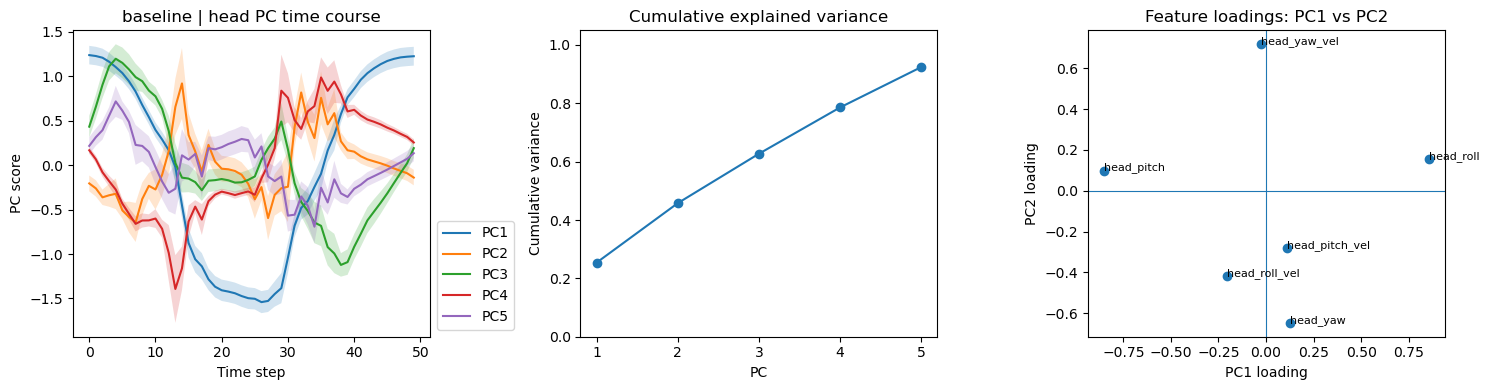

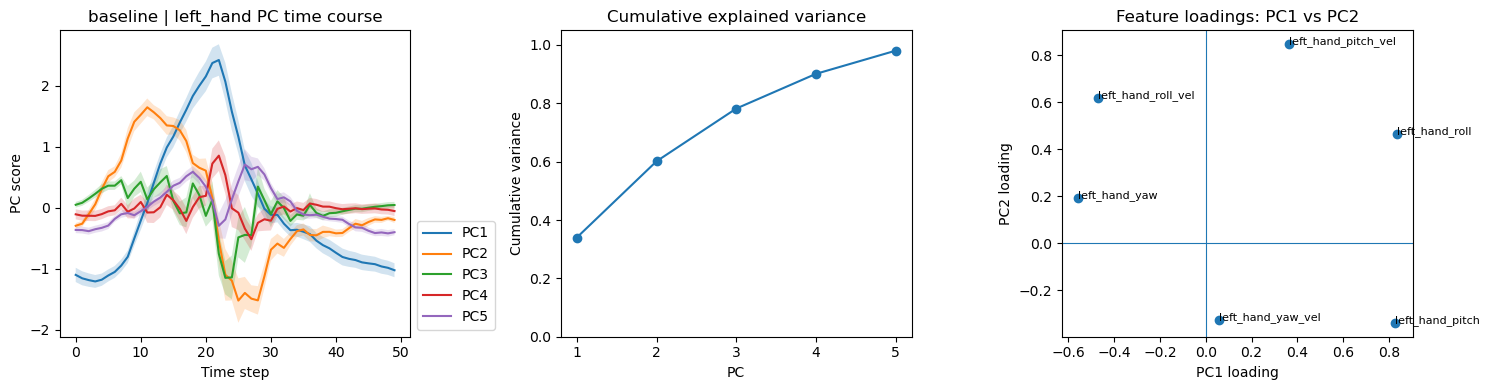

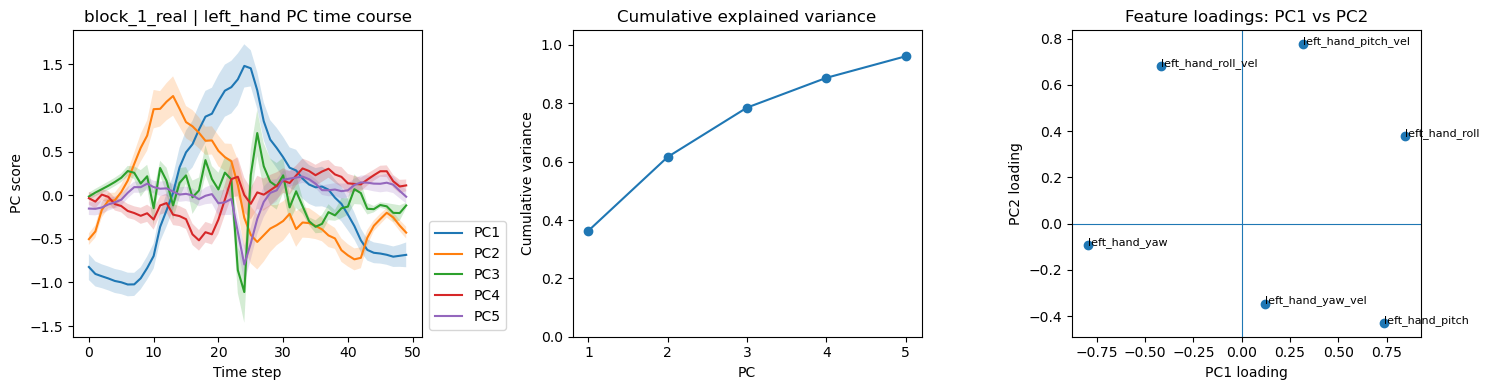

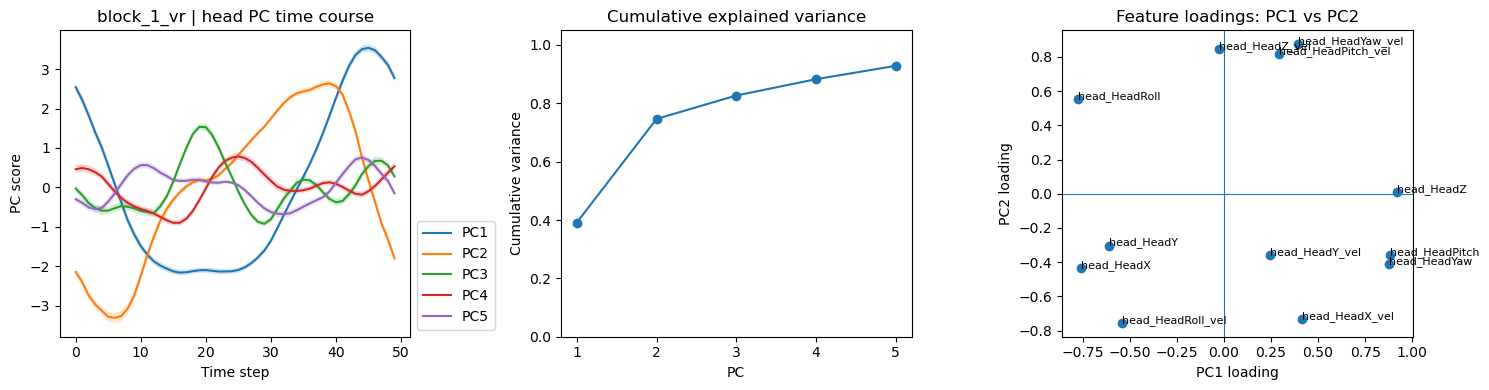

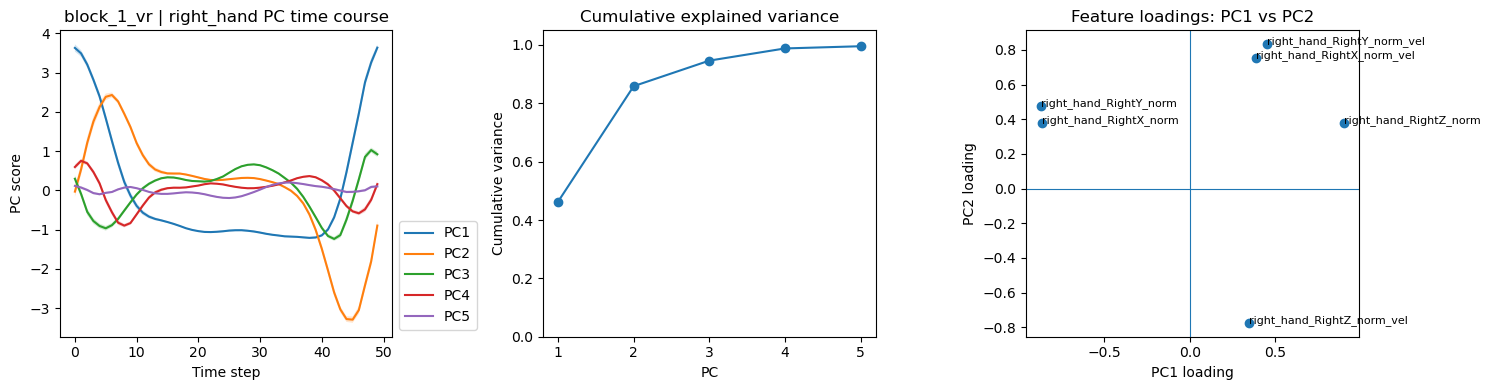

In [ ]:
# baseline real sensor, head
res_base_head = run_group_pca_on_part(
    swim_dict,
    sub_nums=sub_nums,
    part="head",
    block=None,
    modality=None,
    n_components=5,
)

# baseline real sensor, hand
res_base_head = run_group_pca_on_part(
    swim_dict,
    sub_nums=sub_nums,
    part="left_hand",
    block=None,
    modality=None,
    n_components=5,
)

# block 1 real, left hand
res_b1_real_hand = run_group_pca_on_part(
    swim_dict,
    sub_nums=sub_nums,
    part="left_hand",
    block=1,
    modality="real",
    n_components=5,
)

# block 1 vr, head
res_b1_vr_head = run_group_pca_on_part(
    swim_dict,
    sub_nums=sub_nums,
    part="head",
    block=1,
    modality="vr",
    n_components=5,
)

# block 1 vr, right hand
res_b1_vr_rhand = run_group_pca_on_part(
    swim_dict,
    sub_nums=sub_nums,
    part="right_hand",
    block=1,
    modality="vr",
    n_components=5,
)

In [140]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA, PLSRegression


def _get_X_cols(swim_dict, sub, block=None, modality=None):
    sub_key = f"sub_{sub}"

    if block is None:
        X = swim_dict[sub_key]["baseline"]
        cols = swim_dict[sub_key]["feature_cols"]["baseline"]
        label = "baseline"
    else:
        block_key = f"block_{block}"
        X = swim_dict[sub_key][block_key][modality]
        cols = swim_dict[sub_key]["feature_cols"][f"{block_key}_{modality}"]
        label = f"{block_key}_{modality}"

    return X, cols, label


def _select_part_cols(cols, part, use_vel=True):
    idx = [i for i, c in enumerate(cols) if c.startswith(part)]
    if not use_vel:
        idx = [i for i in idx if not cols[i].endswith("_vel")]
    names = [cols[i] for i in idx]
    return idx, names


def _fit_part_pca(X_all, n_components=3, standardize=True):
    """
    X_all: (N, T, D)
    """
    N, T, D = X_all.shape
    X_flat = X_all.reshape(N * T, D)

    scaler = None
    if standardize:
        scaler = StandardScaler()
        X_flat_use = scaler.fit_transform(X_flat)
    else:
        X_flat_use = X_flat

    n_components = min(n_components, D)
    pca = PCA(n_components=n_components)
    pca.fit(X_flat_use)

    return pca, scaler


def _transform_part_pca(X, pca, scaler=None):
    N, T, D = X.shape
    X_flat = X.reshape(N * T, D)

    if scaler is not None:
        X_flat = scaler.transform(X_flat)

    Z = pca.transform(X_flat)
    Z = Z.reshape(N, T, -1)
    return Z


def _peak_amp_lat(Z, peak_mode="abs"):
    """
    Z: (N, T, n_pc)

    Returns
    -------
    peak_amp: (N, n_pc)
    peak_lat: (N, n_pc)
    """
    N, T, K = Z.shape
    peak_amp = np.zeros((N, K))
    peak_lat = np.zeros((N, K))

    for k in range(K):
        z = Z[:, :, k]

        if peak_mode == "abs":
            idx = np.argmax(np.abs(z), axis=1)
        elif peak_mode == "max":
            idx = np.argmax(z, axis=1)
        elif peak_mode == "min":
            idx = np.argmin(z, axis=1)
        else:
            raise ValueError("peak_mode must be 'abs', 'max', or 'min'.")

        peak_lat[:, k] = idx
        peak_amp[:, k] = z[np.arange(N), idx]

    return peak_amp, peak_lat


def _fit_head_hand_model(
    X_head_all,
    X_hand_all,
    method="pls",
    n_components=3,
    standardize=True,
):
    """
    Fit PLS/CCA on original feature space.
    Input: (N, T, D)
    Flattened as (N*T, D)
    """
    Nh, T, Dh = X_head_all.shape
    Xh = X_head_all.reshape(Nh * T, Dh)
    Xg = X_hand_all.reshape(Nh * T, X_hand_all.shape[-1])

    sx, sy = None, None
    if standardize:
        sx = StandardScaler()
        sy = StandardScaler()
        Xh_use = sx.fit_transform(Xh)
        Xg_use = sy.fit_transform(Xg)
    else:
        Xh_use = Xh
        Xg_use = Xg

    n_components = min(n_components, Xh_use.shape[1], Xg_use.shape[1])

    if method == "cca":
        model = CCA(n_components=n_components, max_iter=1000)
    elif method == "pls":
        model = PLSRegression(n_components=n_components)
    else:
        raise ValueError("method must be 'pls' or 'cca'.")

    model.fit(Xh_use, Xg_use)

    return model, sx, sy


def _rep_head_hand_corr(
    X_head,
    X_hand,
    model,
    sx=None,
    sy=None,
    corr_mode="first_component",
):
    """
    Return per-rep head-hand latent correlation.

    X_head, X_hand: (N, T, D)
    """
    N, T, Dh = X_head.shape
    Dg = X_hand.shape[-1]

    Xh = X_head.reshape(N * T, Dh)
    Xg = X_hand.reshape(N * T, Dg)

    if sx is not None:
        Xh = sx.transform(Xh)
    if sy is not None:
        Xg = sy.transform(Xg)

    Zh, Zg = model.transform(Xh, Xg)

    K = Zh.shape[1]
    Zh = Zh.reshape(N, T, K)
    Zg = Zg.reshape(N, T, K)

    corr_each = np.full((N, K), np.nan)

    for n in range(N):
        for k in range(K):
            x = Zh[n, :, k]
            y = Zg[n, :, k]

            if np.std(x) < 1e-8 or np.std(y) < 1e-8:
                corr_each[n, k] = np.nan
            else:
                corr_each[n, k] = np.corrcoef(x, y)[0, 1]

    if corr_mode == "first_component":
        corr_summary = corr_each[:, 0]
    elif corr_mode == "component_avg":
        corr_summary = np.nanmean(corr_each, axis=1)
    else:
        raise ValueError("corr_mode must be 'first_component' or 'component_avg'.")

    return corr_summary, corr_each


def build_rep_window_summary(
    swim_dict,
    sub_nums,
    blocks=(1,),
    modalities=("real", "vr"),
    n_pca_components=3,
    n_cross_components=3,
    cross_method="pls",        # "pls" or "cca"
    corr_mode="first_component",  # "first_component" or "component_avg"
    use_vel=True,
    peak_mode="abs",
    standardize=True,
):
    """
    Build rep-level summary.

    Output structure mirrors swim_dict:

    summary_dict["sub_2"]["baseline"] -> (N, D_summary)
    summary_dict["sub_2"]["block_1"]["real"] -> (N, D_summary)
    summary_dict["sub_2"]["block_1"]["vr"] -> (N, D_summary)

    Note:
    - real hand uses left_hand
    - vr hand also only uses left_hand
    """

    summary_dict = {}
    model_dict = {}

    dataset_specs = [("baseline", None, None)]

    for block in blocks:
        for modality in modalities:
            dataset_specs.append((f"block_{block}_{modality}", block, modality))

    for label, block, modality in dataset_specs:

        # -------------------------
        # 1) collect group data
        # -------------------------
        X_head_all = []
        X_hand_all = []

        head_names_ref = None
        hand_names_ref = None

        for sub in sub_nums:
            X, cols, _ = _get_X_cols(swim_dict, sub, block=block, modality=modality)

            head_idx, head_names = _select_part_cols(cols, "head", use_vel=use_vel)

            # important: VR hand only uses left_hand
            hand_idx, hand_names = _select_part_cols(cols, "left_hand", use_vel=use_vel)

            if head_names_ref is None:
                head_names_ref = head_names
                hand_names_ref = hand_names
            else:
                if head_names != head_names_ref:
                    raise ValueError(f"Head feature mismatch in sub_{sub}, {label}")
                if hand_names != hand_names_ref:
                    raise ValueError(f"Hand feature mismatch in sub_{sub}, {label}")

            X_head_all.append(X[:, :, head_idx])
            X_hand_all.append(X[:, :, hand_idx])

        X_head_all = np.concatenate(X_head_all, axis=0)
        X_hand_all = np.concatenate(X_hand_all, axis=0)

        # -------------------------
        # 2) fit group-level PCA
        # -------------------------
        head_pca, head_scaler = _fit_part_pca(
            X_head_all,
            n_components=n_pca_components,
            standardize=standardize,
        )

        hand_pca, hand_scaler = _fit_part_pca(
            X_hand_all,
            n_components=n_pca_components,
            standardize=standardize,
        )

        # -------------------------
        # 3) fit head-hand PLS/CCA
        # -------------------------
        cross_model, cross_sx, cross_sy = _fit_head_hand_model(
            X_head_all,
            X_hand_all,
            method=cross_method,
            n_components=n_cross_components,
            standardize=standardize,
        )

        model_dict[label] = {
            "head_pca": head_pca,
            "hand_pca": hand_pca,
            "head_scaler": head_scaler,
            "hand_scaler": hand_scaler,
            "cross_model": cross_model,
            "cross_sx": cross_sx,
            "cross_sy": cross_sy,
            "head_feature_names": head_names_ref,
            "hand_feature_names": hand_names_ref,
        }

        # -------------------------
        # 4) build feature names
        # -------------------------
        summary_cols = []

        for k in range(head_pca.n_components_):
            summary_cols += [
                f"head_PC{k+1}_peak_amp",
                f"head_PC{k+1}_peak_lat",
            ]

        for k in range(hand_pca.n_components_):
            summary_cols += [
                f"hand_PC{k+1}_peak_amp",
                f"hand_PC{k+1}_peak_lat",
            ]

        n_lag = min(head_pca.n_components_, hand_pca.n_components_)
        for k in range(n_lag):
            summary_cols.append(f"head_hand_PC{k+1}_peak_lat_lag")

        summary_cols.append(f"head_hand_{cross_method}_{corr_mode}_corr")

        for k in range(min(n_cross_components, cross_model.x_weights_.shape[1])):
            summary_cols.append(f"head_hand_{cross_method}_comp{k+1}_corr")

        # -------------------------
        # 5) summarize each subject
        # -------------------------
        for sub in sub_nums:
            sub_key = f"sub_{sub}"
            if sub_key not in summary_dict:
                summary_dict[sub_key] = {"feature_cols": {}}

            X, cols, _ = _get_X_cols(swim_dict, sub, block=block, modality=modality)

            head_idx, _ = _select_part_cols(cols, "head", use_vel=use_vel)
            hand_idx, _ = _select_part_cols(cols, "left_hand", use_vel=use_vel)

            X_head = X[:, :, head_idx]
            X_hand = X[:, :, hand_idx]

            Z_head = _transform_part_pca(X_head, head_pca, head_scaler)
            Z_hand = _transform_part_pca(X_hand, hand_pca, hand_scaler)

            head_amp, head_lat = _peak_amp_lat(Z_head, peak_mode=peak_mode)
            hand_amp, hand_lat = _peak_amp_lat(Z_hand, peak_mode=peak_mode)

            lag = hand_lat[:, :n_lag] - head_lat[:, :n_lag]

            corr_summary, corr_each = _rep_head_hand_corr(
                X_head,
                X_hand,
                cross_model,
                sx=cross_sx,
                sy=cross_sy,
                corr_mode=corr_mode,
            )

            parts = []

            for k in range(head_pca.n_components_):
                parts.append(head_amp[:, [k]])
                parts.append(head_lat[:, [k]])

            for k in range(hand_pca.n_components_):
                parts.append(hand_amp[:, [k]])
                parts.append(hand_lat[:, [k]])

            parts.append(lag)
            parts.append(corr_summary[:, None])
            parts.append(corr_each)

            summary_X = np.concatenate(parts, axis=1)

            if block is None:
                summary_dict[sub_key]["baseline"] = summary_X
                summary_dict[sub_key]["feature_cols"]["baseline"] = summary_cols
            else:
                block_key = f"block_{block}"
                if block_key not in summary_dict[sub_key]:
                    summary_dict[sub_key][block_key] = {}

                summary_dict[sub_key][block_key][modality] = summary_X
                summary_dict[sub_key]["feature_cols"][f"{block_key}_{modality}"] = summary_cols

    return summary_dict, model_dict

In [ ]:
rep_summary_dict, rep_summary_models = build_rep_window_summary(
    swim_dict,
    sub_nums=sub_nums,
    blocks=(1,),
    modalities=("real", "vr"),
    n_pca_components=3,
    n_cross_components=3,
    cross_method="pls",          # or "cca"
    corr_mode="first_component", # or "component_avg"
    use_vel=True,
    peak_mode="abs",
)

In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests


def _find_summary_features(feature_cols, features_to_observe=("lag", "correlation")):
    selected = []

    for feat in feature_cols:
        f = feat.lower()

        for key in features_to_observe:
            key = key.lower()

            if key == "lag":
                if "lag" in f:
                    selected.append(feat)

            elif key in ["correlation", "corr"]:
                if "corr" in f:
                    selected.append(feat)

            else:
                if key in f:
                    selected.append(feat)

    return selected


def _rolling_1d(x, n_rolling_reps=3):
    """
    causal rolling mean:
    rep i = mean of [i-n+1, ..., i]
    """
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)

    for i in range(len(x)):
        start = max(0, i - n_rolling_reps + 1)
        out[i] = np.nanmean(x[start:i+1])

    return out


def _paired_test(x_prev, x_curr, method="ttest"):
    mask = np.isfinite(x_prev) & np.isfinite(x_curr)
    x_prev = x_prev[mask]
    x_curr = x_curr[mask]

    if len(x_prev) < 3:
        return np.nan

    if np.nanstd(x_curr - x_prev) < 1e-12:
        return np.nan

    if method == "ttest":
        return ttest_rel(x_curr, x_prev).pvalue

    elif method == "wilcoxon":
        try:
            return wilcoxon(x_curr, x_prev).pvalue
        except ValueError:
            return np.nan

    else:
        raise ValueError("method must be 'ttest' or 'wilcoxon'.")


def plot_rep_summary_over_reps(
    rep_summary_dict,
    sub_nums,
    blocks=(1,),
    modalities=("real", "vr"),
    features_to_observe=("lag", "correlation"),
    reps_to_observe=(0, 15),
    n_rolling_reps=3,
    test_method="ttest",      # "ttest" or "wilcoxon"
    b_use_fdr=True,
    alpha=0.05,
    figsize_per_subplot=(5, 3),
):
    """
    Plot subject-average rep summary dynamics.

    Parameters
    ----------
    rep_summary_dict : dict
        Output from build_rep_window_summary.
    sub_nums : list[int]
    blocks : tuple[int]
    modalities : tuple[str]
    features_to_observe : tuple[str]
        e.g. ("lag", "correlation")
    reps_to_observe : tuple[int, int]
        inclusive-exclusive range, e.g. (0, 15)
    n_rolling_reps : int
        Rolling average over reps within each subject.
    test_method : str
        "ttest" or "wilcoxon"
    b_use_fdr : bool
        Correct p-values across adjacent-rep tests within each subplot-feature.
    """

    dataset_specs = [("baseline", None, None)]

    for block in blocks:
        for modality in modalities:
            dataset_specs.append((f"block_{block}_{modality}", block, modality))

    n_panels = len(dataset_specs)
    fig, axes = plt.subplots(
        1,
        n_panels,
        figsize=(figsize_per_subplot[0] * n_panels, figsize_per_subplot[1]),
        sharex=False,
        sharey=False,
    )

    if n_panels == 1:
        axes = [axes]

    all_stat_rows = []

    for i, (ax, (panel_name, block, modality)) in enumerate(zip(axes, dataset_specs)):

        # -------------------------
        # get feature cols
        # -------------------------
        first_sub_key = f"sub_{sub_nums[0]}"

        if block is None:
            feature_cols = rep_summary_dict[first_sub_key]["feature_cols"]["baseline"]
        else:
            block_key = f"block_{block}"
            feature_cols = rep_summary_dict[first_sub_key]["feature_cols"][f"{block_key}_{modality}"]

        selected_features = _find_summary_features(
            feature_cols,
            features_to_observe=features_to_observe,
        )

        if len(selected_features) == 0:
            raise ValueError(
                f"No matching features found for {features_to_observe} in {panel_name}."
            )

        start_rep, end_rep = reps_to_observe
        rep_x = np.arange(start_rep, end_rep)

        # -------------------------
        # plot each summary feature
        # -------------------------
        for feat in selected_features:
            feat_idx = feature_cols.index(feat)

            subj_curves = []

            for sub in sub_nums:
                sub_key = f"sub_{sub}"

                if block is None:
                    X = rep_summary_dict[sub_key]["baseline"]
                else:
                    block_key = f"block_{block}"
                    X = rep_summary_dict[sub_key][block_key][modality]

                vals = X[:, feat_idx]
                vals_roll = _rolling_1d(vals, n_rolling_reps=n_rolling_reps)

                vals_obs = vals_roll[start_rep:end_rep]
                subj_curves.append(vals_obs)

            subj_curves = np.asarray(subj_curves)  # (n_sub, n_reps)

            mean = np.nanmean(subj_curves, axis=0)
            sem = np.nanstd(subj_curves, axis=0, ddof=1) / np.sqrt(subj_curves.shape[0])

            line = ax.plot(rep_x, mean, marker="o", label=feat)[0]
            color = line.get_color()

            ax.fill_between(
                rep_x,
                mean - sem,
                mean + sem,
                alpha=0.2,
                color=color,
            )

            # -------------------------
            # adjacent-rep paired tests
            # -------------------------
            pvals = []
            test_reps = []

            for j in range(1, subj_curves.shape[1]):
                x_prev = subj_curves[:, j - 1]
                x_curr = subj_curves[:, j]

                p = _paired_test(x_prev, x_curr, method=test_method)
                pvals.append(p)
                test_reps.append(rep_x[j])

            pvals = np.asarray(pvals, dtype=float)

            if b_use_fdr:
                valid = np.isfinite(pvals)
                pvals_corr = np.full_like(pvals, np.nan, dtype=float)

                if valid.sum() > 0:
                    _, pvals_corr_valid, _, _ = multipletests(
                        pvals[valid],
                        alpha=alpha,
                        method="fdr_bh",
                    )
                    pvals_corr[valid] = pvals_corr_valid
            else:
                pvals_corr = pvals

            sig_mask = np.isfinite(pvals_corr) & (pvals_corr < alpha)

            # mark significant reps
            if sig_mask.any():
                y_sig = mean[1:][sig_mask]
                x_sig = np.asarray(test_reps)[sig_mask]

                offset = 0.04 * (np.nanmax(mean + sem) - np.nanmin(mean - sem) + 1e-8)

                ax.scatter(
                    x_sig,
                    y_sig + offset,
                    marker="*",
                    s=80,
                    color=color,
                    zorder=5,
                )

            for rep_id, p_raw, p_corr in zip(test_reps, pvals, pvals_corr):
                all_stat_rows.append({
                    "panel": panel_name,
                    "feature": feat,
                    "rep": rep_id,
                    "compare": f"rep_{rep_id} vs rep_{rep_id - 1}",
                    "test": test_method,
                    "p_raw": p_raw,
                    "p_corr": p_corr,
                    "significant": bool(np.isfinite(p_corr) and p_corr < alpha),
                    "fdr": b_use_fdr,
                })

        ax.set_title(panel_name)
        ax.set_xlabel("Rep number")
        ax.set_xticks(np.arange(reps_to_observe[0], reps_to_observe[1]+1, 2))
        ax.set_ylabel("Subject average summary")
        ax.axhline(0, linewidth=0.8, alpha=0.5)
        if i != n_panels-1:
            continue
        ax.legend(bbox_to_anchor=(1.0,0), loc="lower left", fontsize=8)

    plt.tight_layout()
    plt.show()

    stat_df = pd.DataFrame(all_stat_rows)

    return stat_df

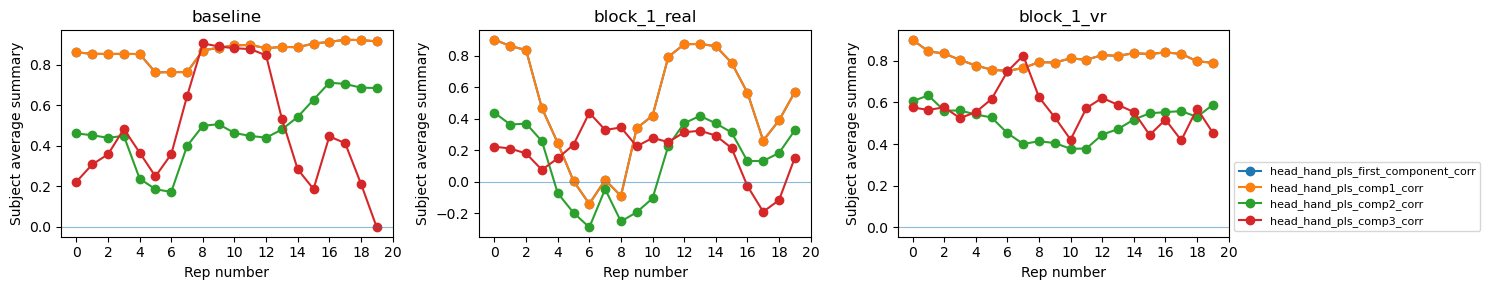

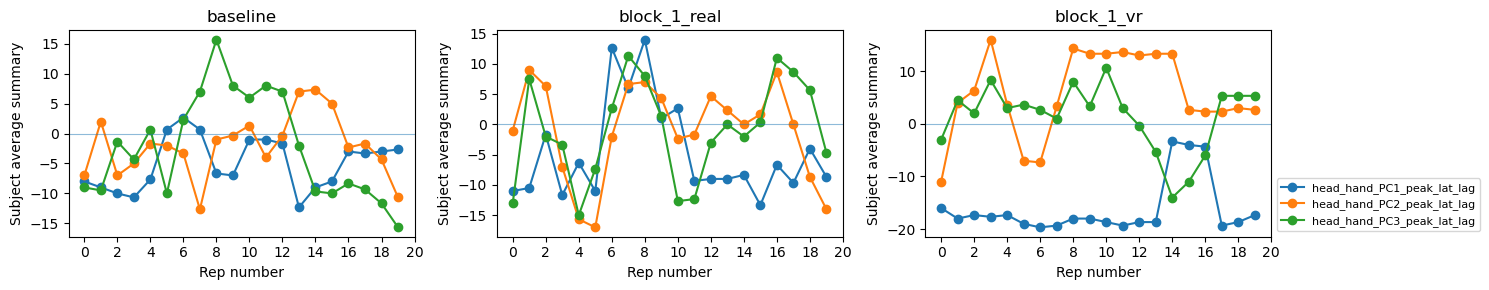

In [ ]:
stat_df = plot_rep_summary_over_reps(
    rep_summary_dict,
    sub_nums=sub_nums,
    blocks=(1,),
    modalities=("real", "vr"),
    features_to_observe=("correlation",),
    reps_to_observe=(0, 20),
    n_rolling_reps=3,
    test_method="ttest",
    b_use_fdr=True,
    alpha=0.05,
)

stat_df = plot_rep_summary_over_reps(
    rep_summary_dict,
    sub_nums=sub_nums,
    blocks=(1,),
    modalities=("real", "vr"),
    features_to_observe=("lag",),
    reps_to_observe=(0, 20),
    n_rolling_reps=3,
    test_method="ttest",
    b_use_fdr=True,
    alpha=0.05,
)

In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde, ttest_rel, wilcoxon, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests


def _find_summary_features(feature_cols, features_to_observe=("lag", "correlation")):
    selected = []

    for feat in feature_cols:
        f = feat.lower()

        for key in features_to_observe:
            key = key.lower()

            if key == "lag":
                if "lag" in f:
                    selected.append(feat)

            elif key in ["correlation", "corr"]:
                if "corr" in f:
                    selected.append(feat)

            else:
                if key in f:
                    selected.append(feat)

    return selected


def _get_summary_X_and_cols(rep_summary_dict, sub, block=None, modality=None):
    sub_key = f"sub_{sub}"

    if block is None:
        X = rep_summary_dict[sub_key]["baseline"]
        cols = rep_summary_dict[sub_key]["feature_cols"]["baseline"]
        label = "baseline"
    else:
        block_key = f"block_{block}"
        X = rep_summary_dict[sub_key][block_key][modality]
        cols = rep_summary_dict[sub_key]["feature_cols"][f"{block_key}_{modality}"]
        label = f"{block_key}_{modality}"

    return X, cols, label


def _safe_kde_plot(ax, values, label, linewidth=2):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 3 or np.nanstd(values) < 1e-10:
        ax.axvline(np.nanmean(values), linestyle="--", linewidth=linewidth, label=label)
        return

    xs = np.linspace(np.nanmin(values), np.nanmax(values), 200)
    kde = gaussian_kde(values)
    ys = kde(xs)

    ax.plot(xs, ys, linewidth=linewidth, label=label)


def _test_baseline_vs_block(
    baseline_vals,
    block_vals,
    paired=True,
    method="ttest",
):
    baseline_vals = np.asarray(baseline_vals, dtype=float)
    block_vals = np.asarray(block_vals, dtype=float)

    if paired:
        mask = np.isfinite(baseline_vals) & np.isfinite(block_vals)
        x = baseline_vals[mask]
        y = block_vals[mask]

        if len(x) < 3:
            return np.nan

        if np.nanstd(y - x) < 1e-12:
            return np.nan

        if method == "ttest":
            return ttest_rel(y, x).pvalue
        elif method == "wilcoxon":
            try:
                return wilcoxon(y, x).pvalue
            except ValueError:
                return np.nan
        else:
            raise ValueError("method must be 'ttest' or 'wilcoxon'.")

    else:
        x = baseline_vals[np.isfinite(baseline_vals)]
        y = block_vals[np.isfinite(block_vals)]

        if len(x) < 3 or len(y) < 3:
            return np.nan

        if method == "ttest":
            return ttest_ind(y, x, equal_var=False).pvalue
        elif method == "wilcoxon":
            return mannwhitneyu(y, x, alternative="two-sided").pvalue
        else:
            raise ValueError("method must be 'ttest' or 'wilcoxon'.")


def plot_block_feature_distribution_vs_baseline(
    rep_summary_dict,
    sub_nums,
    blocks=(1,),
    modalities=("real", "vr"),
    features_to_observe=("lag", "correlation"),
    reps_to_observe=None,
    mode="group",              # "group" or "single_subject"
    subject_agg="mean",        # "mean" or "median", only for group mode
    test_method="ttest",       # group: paired ttest/wilcoxon; single: Welch ttest/Mann-Whitney
    b_use_fdr=True,
    alpha=0.05,
    figsize_per_panel=(4.5, 3.2),
):
    """
    Plot distribution curves for block features and test block vs baseline.

    mode="group":
        For each subject, aggregate reps into one value.
        Then compare block vs baseline across subjects.

    mode="single_subject":
        For each subject, compare that subject's block reps vs baseline reps.
        Each subject is plotted separately.
    """

    if mode not in ["group", "single_subject"]:
        raise ValueError("mode must be 'group' or 'single_subject'.")

    if subject_agg not in ["mean", "median"]:
        raise ValueError("subject_agg must be 'mean' or 'median'.")

    first_sub = sub_nums[0]
    _, base_cols, _ = _get_summary_X_and_cols(rep_summary_dict, first_sub, block=None)
    selected_features = _find_summary_features(base_cols, features_to_observe)

    if len(selected_features) == 0:
        raise ValueError(f"No matching features found for {features_to_observe}.")

    dataset_specs = []
    for block in blocks:
        for modality in modalities:
            dataset_specs.append((block, modality, f"block_{block}_{modality}"))

    stat_rows = []

    if mode == "group":
        n_rows = len(selected_features)
        n_cols = len(dataset_specs)

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
            squeeze=False,
        )

        for r, feat in enumerate(selected_features):
            for c, (block, modality, panel_name) in enumerate(dataset_specs):
                ax = axes[r, c]

                baseline_subject_vals = []
                block_subject_vals = []

                for sub in sub_nums:
                    X_base, base_cols, _ = _get_summary_X_and_cols(
                        rep_summary_dict, sub, block=None
                    )
                    X_block, block_cols, _ = _get_summary_X_and_cols(
                        rep_summary_dict, sub, block=block, modality=modality
                    )

                    if feat not in base_cols or feat not in block_cols:
                        continue

                    base_idx = base_cols.index(feat)
                    block_idx = block_cols.index(feat)

                    base_vals = X_base[:, base_idx]
                    block_vals = X_block[:, block_idx]

                    if reps_to_observe is not None:
                        s, e = reps_to_observe
                        base_vals = base_vals[s:e]
                        block_vals = block_vals[s:e]

                    if subject_agg == "mean":
                        baseline_subject_vals.append(np.nanmean(base_vals))
                        block_subject_vals.append(np.nanmean(block_vals))
                    else:
                        baseline_subject_vals.append(np.nanmedian(base_vals))
                        block_subject_vals.append(np.nanmedian(block_vals))

                baseline_subject_vals = np.asarray(baseline_subject_vals)
                block_subject_vals = np.asarray(block_subject_vals)

                p_raw = _test_baseline_vs_block(
                    baseline_subject_vals,
                    block_subject_vals,
                    paired=True,
                    method=test_method,
                )

                stat_rows.append({
                    "mode": mode,
                    "feature": feat,
                    "block": block,
                    "modality": modality,
                    "panel": panel_name,
                    "test": f"paired_{test_method}",
                    "p_raw": p_raw,
                    "n_subjects": len(baseline_subject_vals),
                })

                _safe_kde_plot(ax, baseline_subject_vals, "baseline")
                _safe_kde_plot(ax, block_subject_vals, panel_name)

                ax.axvline(np.nanmean(baseline_subject_vals), linestyle="--", alpha=0.7)
                ax.axvline(np.nanmean(block_subject_vals), linestyle="--", alpha=0.7)

                ax.set_title(f"{feat}\n{panel_name}")
                ax.set_xlabel("Subject-level summary")
                ax.set_ylabel("Density")
                ax.legend(fontsize=8)

        stat_df = pd.DataFrame(stat_rows)

        if b_use_fdr and len(stat_df) > 0:
            valid = stat_df["p_raw"].notna().values
            stat_df["p_corr"] = np.nan

            if valid.sum() > 0:
                _, p_corr, _, _ = multipletests(
                    stat_df.loc[valid, "p_raw"].values,
                    alpha=alpha,
                    method="fdr_bh",
                )
                stat_df.loc[valid, "p_corr"] = p_corr
        else:
            stat_df["p_corr"] = stat_df["p_raw"]

        stat_df["significant"] = stat_df["p_corr"] < alpha

        for _, row in stat_df.iterrows():
            if row["significant"]:
                r = selected_features.index(row["feature"])
                c = [x[2] for x in dataset_specs].index(row["panel"])
                axes[r, c].text(
                    0.95, 0.95, "*",
                    transform=axes[r, c].transAxes,
                    ha="right",
                    va="top",
                    fontsize=18,
                    fontweight="bold",
                )

        plt.tight_layout()
        plt.show()

        return stat_df

    else:
        n_rows = len(sub_nums)
        n_cols = len(selected_features) * len(dataset_specs)

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
            squeeze=False,
        )

        for r, sub in enumerate(sub_nums):
            col_id = 0

            for feat in selected_features:
                for block, modality, panel_name in dataset_specs:
                    ax = axes[r, col_id]
                    col_id += 1

                    X_base, base_cols, _ = _get_summary_X_and_cols(
                        rep_summary_dict, sub, block=None
                    )
                    X_block, block_cols, _ = _get_summary_X_and_cols(
                        rep_summary_dict, sub, block=block, modality=modality
                    )

                    if feat not in base_cols or feat not in block_cols:
                        ax.set_axis_off()
                        continue

                    base_idx = base_cols.index(feat)
                    block_idx = block_cols.index(feat)

                    base_vals = X_base[:, base_idx]
                    block_vals = X_block[:, block_idx]

                    if reps_to_observe is not None:
                        s, e = reps_to_observe
                        base_vals = base_vals[s:e]
                        block_vals = block_vals[s:e]

                    p_raw = _test_baseline_vs_block(
                        base_vals,
                        block_vals,
                        paired=False,
                        method=test_method,
                    )

                    stat_rows.append({
                        "mode": mode,
                        "sub": sub,
                        "feature": feat,
                        "block": block,
                        "modality": modality,
                        "panel": panel_name,
                        "test": f"within_subject_{test_method}",
                        "p_raw": p_raw,
                        "n_baseline_reps": np.isfinite(base_vals).sum(),
                        "n_block_reps": np.isfinite(block_vals).sum(),
                    })

                    _safe_kde_plot(ax, base_vals, "baseline")
                    _safe_kde_plot(ax, block_vals, panel_name)

                    ax.axvline(np.nanmean(base_vals), linestyle="--", alpha=0.7)
                    ax.axvline(np.nanmean(block_vals), linestyle="--", alpha=0.7)

                    ax.set_title(f"sub_{sub} | {feat}\n{panel_name}")
                    ax.set_xlabel("Rep-level value")
                    ax.set_ylabel("Density")
                    ax.legend(fontsize=7)

        stat_df = pd.DataFrame(stat_rows)

        if b_use_fdr and len(stat_df) > 0:
            valid = stat_df["p_raw"].notna().values
            stat_df["p_corr"] = np.nan

            if valid.sum() > 0:
                _, p_corr, _, _ = multipletests(
                    stat_df.loc[valid, "p_raw"].values,
                    alpha=alpha,
                    method="fdr_bh",
                )
                stat_df.loc[valid, "p_corr"] = p_corr
        else:
            stat_df["p_corr"] = stat_df["p_raw"]

        stat_df["significant"] = stat_df["p_corr"] < alpha

        for i, row in stat_df.iterrows():
            if row["significant"]:
                r = sub_nums.index(row["sub"])
                feat_id = selected_features.index(row["feature"])
                panel_id = [x[2] for x in dataset_specs].index(row["panel"])
                c = feat_id * len(dataset_specs) + panel_id

                axes[r, c].text(
                    0.95, 0.95, "*",
                    transform=axes[r, c].transAxes,
                    ha="right",
                    va="top",
                    fontsize=18,
                    fontweight="bold",
                )

        plt.tight_layout()
        plt.show()

        return stat_df

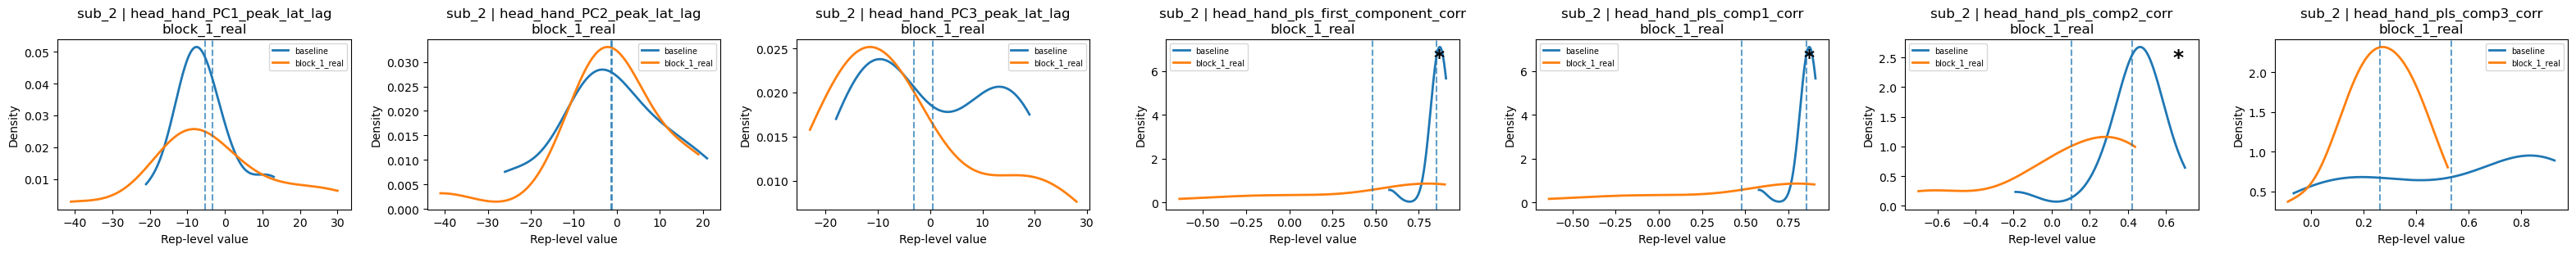

In [171]:
stat_single = plot_block_feature_distribution_vs_baseline(
    rep_summary_dict,
    sub_nums=sub_nums,
    blocks=(1,),
    modalities=("real",),
    features_to_observe=("lag", "correlation"),
    reps_to_observe=(0, 15),
    mode="single_subject",
    test_method="wilcoxon",
    b_use_fdr=True,
)